# Sentiment Analysis in Romance Novel Reviews

In [1]:
import sqlite3
import gzip
import json
import re
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords

In [5]:
# only run once
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/marlena/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
# open romance.db in sqlite3
conn = sqlite3.connect("byGenre/romance.db")
cursor = conn.cursor()

In [7]:
# key reinforcement
cursor.execute("PRAGMA foreign_keys = ON;")

# speed boost
cursor.execute("PRAGMA journal_mode = WAL;")
cursor.execute("PRAGMA synchronous = OFF;")
cursor.execute("PRAGMA temp_store = FILE;")
cursor.execute("PRAGMA cache_size = -200000;")  # ~200MB RAM

## Data Ingestion

Left join reviews with books (preserve all reviews)

Speedups:
1. add indexes on book_id
2. select only certain columns
3. use chunked loading

In [8]:
cursor.execute("""
CREATE INDEX IF NOT EXISTS idx_reviews_book ON reviews(book_id);
""")

cursor.execute("""
CREATE INDEX IF NOT EXISTS idx_books_book ON books(book_id);
""")

conn.commit()

In [9]:
# join book data into reviews table (left join to preserve all reviews)
query = """
SELECT
    r.review_id,
    r.user_id,
    r.book_id,
    r.rating,
    r.review_text,
    b.title,
    b.average_rating,
    b.description
FROM reviews r
LEFT JOIN books b
ON r.book_id = b.book_id
"""

chunks = pd.read_sql_query(query, conn, chunksize=50000)

revs_books = pd.concat(chunks, ignore_index=True)
revs_books.head()

,review_id,user_id,book_id,rating,review_text,title,average_rating,description
0,5347a776a1703b823ce029d68ae98275,8842281e1d1347389f2ab93d60773d4d,1893,5.0,** spoiler alert ** \n So the other day Elizab...,Pride and Prejudice,4.25,"'It is a truth universally acknowledged, that ..."
1,719711cc71eec0bb54d2d97322c0e11b,72fb0d0087d28c832f15776b0d936598,17939501,5.0,"It is very hard to believe this is all true, b...",The Brothel (Confidante Trilogy #1),3.50,Librarian's note: This is an alternate cover e...
2,6a870a66f732183b60214d57fa553093,72fb0d0087d28c832f15776b0d936598,15706923,2.0,Ehhhhhh. \n Really nothing to rave about. It w...,Bloodwine,3.29,Fifty years of war with the humans and the los...
3,f73a70f64564d4a8f4cfb2d2e9d5836f,72fb0d0087d28c832f15776b0d936598,7840190,4.0,Enjoyable read! I liked that Connie is not a t...,"Bait (Angler, #1)",3.70,Live bait makes all the difference.\nSent on a...
4,547aeff3c7ee5b4a39a93cd2a720b001,72fb0d0087d28c832f15776b0d936598,15463724,4.0,There are definitely too many books lately wit...,Hunger of the Wolf,3.65,Amber Lee is going through a painful divorce w...


In [10]:
print(len(revs_books['book_id']))
revs_books.isnull().sum()

3565378


review_id         0
user_id           0
book_id           0
rating            0
review_text       0
title             0
average_rating    0
description       0
dtype: int64

In [11]:
revs_books['rating'].describe()

count    3.565378e+06
mean     3.890471e+00
std      1.242781e+00
min      0.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [12]:
sum(revs_books['rating'] == 0)

115147

## Clean up Review Texts

In [13]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    
    # remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # remove numbers
    text = re.sub(r"\d+", "", text)
    
    # remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words]
    
    return " ".join(words)

In [14]:
# clean text to remove stopwords
revs_books["clean_review"] = revs_books["review_text"].apply(clean_text)

revs_books[["review_text", "clean_review"]].head()

,review_text,clean_review
0,** spoiler alert ** \n So the other day Elizab...,spoiler alert day elizabeth book store saw boo...
1,"It is very hard to believe this is all true, b...",hard believe true ill take authors word ive al...
2,Ehhhhhh. \n Really nothing to rave about. It w...,ehhhhhh really nothing rave poorly written ter...
3,Enjoyable read! I liked that Connie is not a t...,enjoyable read liked connie typical coldhearte...
4,There are definitely too many books lately wit...,definitely many books lately theme woman going...


In [15]:
# make word count feature
revs_books["review_word_count"] = revs_books["clean_review"].str.split().apply(len)

In [16]:
# remove ratings = 0 and reviews with 0 words
revs_books_filtered = revs_books[revs_books['rating'] > 0]
revs_books_filtered = revs_books_filtered[revs_books_filtered['review_word_count'] > 0]
print(len(revs_books_filtered))

3424690


After cleaning 3,424,690 reviews remain.

In [17]:
#revs_books_filtered.to_csv("byGenre/revs_books_filtered.csv")

In [2]:
revs_books_filtered = pd.read_csv('byGenre/revs_books_filtered.csv')

## Some NLP EDA

In [ ]:
positive = revs_books_filtered[revs_books_filtered["rating"] >= 4]
negative = revs_books_filtered[revs_books_filtered["rating"] <= 2]

In [ ]:
def get_top_words(text_series):
    vec = CountVectorizer(max_features=500)
    X = vec.fit_transform(text_series)
    counts = np.sum(X.toarray(), axis=0)
    words = vec.get_feature_names_out()
    
    return pd.DataFrame({
        "word": words,
        "count": counts
    }).sort_values("count", ascending=False)

In [33]:
get_top_words(positive["clean_review"]).head(25)

,word,count
36,book,3458671
407,story,2027364
259,love,1898999
338,read,1870609
306,one,1669363
344,really,1126865
245,like,1122902
260,loved,1058464
55,characters,1002646
375,series,995711


In [34]:
get_top_words(negative["clean_review"]).head(25)

,word,count
35,book,376598
243,like,214823
409,story,162733
304,one,161501
342,read,155014
347,really,145369
90,didnt,127680
53,characters,107612
255,love,101432
485,would,100514


In [37]:
(len(positive))/(len(negative))

8.25403536998522

Ratio of positive to negative reviews are 8.25 to 1

In [39]:
del positive, negative

In [16]:
revs_books_pos_neg = revs_books_filtered[revs_books_filtered["rating"] != 3]  # remove neutral

revs_books_pos_neg["sentiment"] = revs_books_pos_neg["rating"].apply(lambda x: 1 if x >= 4 else 0)

/var/folders/4y/vrkxrp99271f82n1xn5c8cc80000gn/T/ipykernel_79400/1741510791.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  revs_books_pos_neg["sentiment"] = revs_books_pos_neg["rating"].apply(lambda x: 1 if x >= 4 else 0)


In [17]:
sum(revs_books_pos_neg["sentiment"])

2524051

# NLP Modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

In [19]:
X = revs_books_pos_neg["clean_review"]
y = revs_books_pos_neg["sentiment"]

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [20]:
# TF-IDF: term frequency scaled by inverse document frequency
# reduces the weight of frequently occurring words across all reviews, highlighting unique & meaningful terms
tfidf = TfidfVectorizer(max_features=5000)

# fit transform X_train and apply to X_test
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [21]:
print(tfidf.get_feature_names_out())

['aaron' 'abandoned' 'abbi' ... 'zombie' 'zone' 'zu']


In [24]:
# start with logistic regression as baseline model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
y_pred = lr.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.58      0.68     61159
           1       0.95      0.98      0.97    504811

    accuracy                           0.94    565970
   macro avg       0.89      0.78      0.83    565970
weighted avg       0.94      0.94      0.94    565970



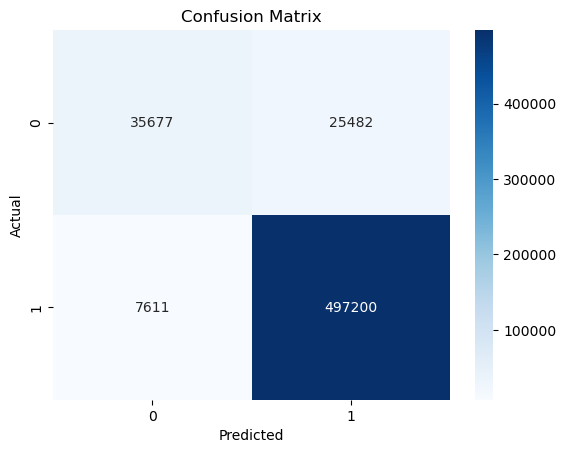

In [40]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

              precision    recall  f1-score   support

           0       0.47      0.89      0.62     61159
           1       0.99      0.88      0.93    504811

    accuracy                           0.88    565970
   macro avg       0.73      0.88      0.77    565970
weighted avg       0.93      0.88      0.89    565970



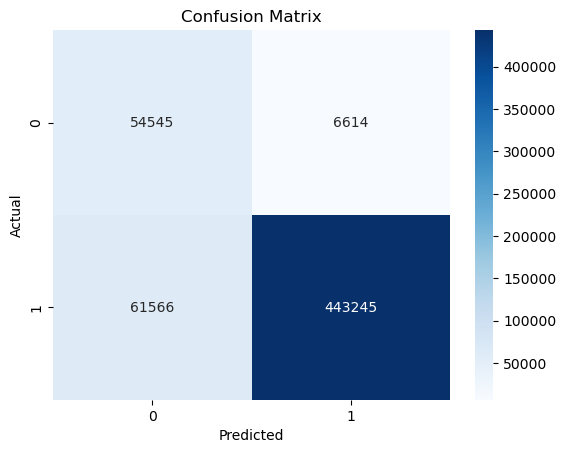

In [41]:
lr_bal = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_bal.fit(X_train_tfidf, y_train)
y_pred = lr_bal.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

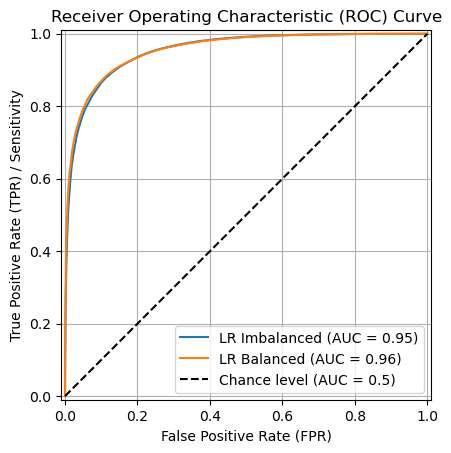

In [45]:
from sklearn.metrics import RocCurveDisplay

# Create the figure and axes
fig, ax = plt.subplots()

# Plot first model
RocCurveDisplay.from_estimator(lr, X_test_tfidf, y_test, ax=ax, name="LR Imbalanced")

# Plot second model on the SAME axes
RocCurveDisplay.from_estimator(lr_bal, X_test_tfidf, y_test, ax=ax, name="LR Balanced")

plt.plot([0, 1], [0, 1], 'k--', label='Chance level (AUC = 0.5)') # Add the random guess line

# 4. Finalize and show the plot
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Sensitivity')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [46]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.52      0.22      0.31     61159
           1       0.91      0.98      0.94    504811

    accuracy                           0.89    565970
   macro avg       0.72      0.60      0.62    565970
weighted avg       0.87      0.89      0.87    565970



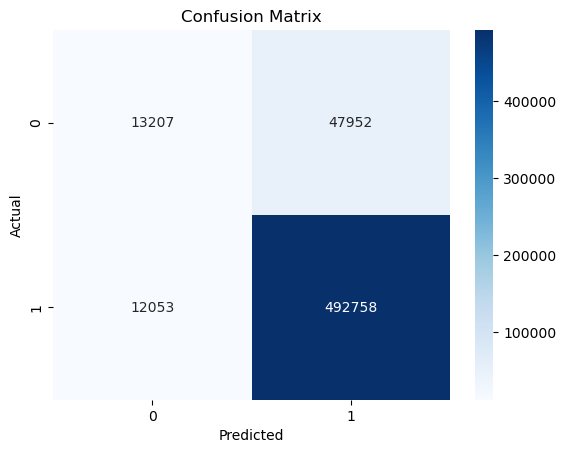

In [47]:
cm = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [48]:
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

nb_bal = MultinomialNB()
nb_bal.fit(X_train_tfidf, y_train, sample_weight=sample_weights)

y_pred_nb = nb_bal.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.41      0.85      0.56     61159
           1       0.98      0.85      0.91    504811

    accuracy                           0.85    565970
   macro avg       0.70      0.85      0.73    565970
weighted avg       0.92      0.85      0.87    565970



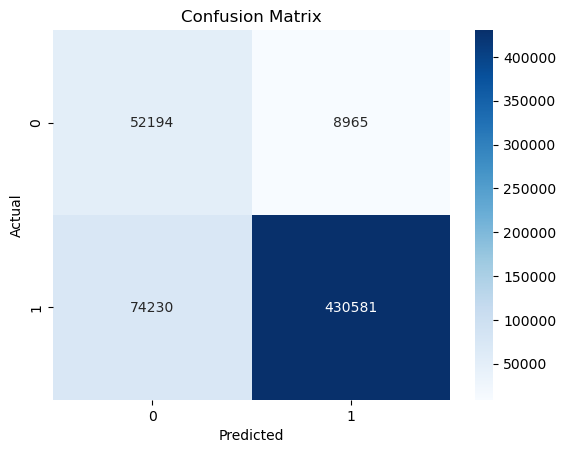

In [49]:
cm = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

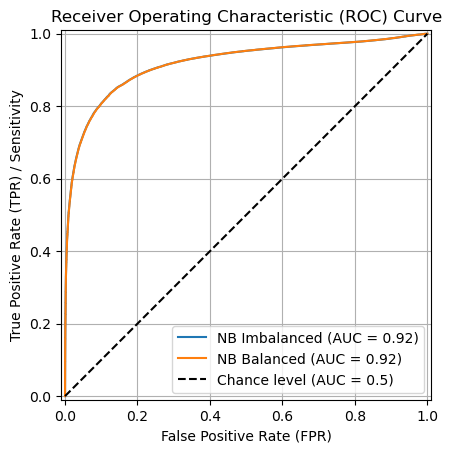

In [50]:
# Create the figure and axes
fig, ax = plt.subplots()

# Plot first model
RocCurveDisplay.from_estimator(nb, X_test_tfidf, y_test, ax=ax, name="NB Imbalanced")

# Plot second model on the SAME axes
RocCurveDisplay.from_estimator(nb_bal, X_test_tfidf, y_test, ax=ax, name="NB Balanced")

plt.plot([0, 1], [0, 1], 'k--', label='Chance level (AUC = 0.5)') # Add the random guess line

# 4. Finalize and show the plot
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Sensitivity')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [36]:
import xgboost 

scale_weight = sum(y_train == 0) / sum(y_train == 1)

xgb = xgboost.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb.fit(X_train_tfidf, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [37]:
y_pred_xgb = xgb.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.35      0.89      0.51     61159
           1       0.98      0.80      0.88    504811

    accuracy                           0.81    565970
   macro avg       0.67      0.85      0.70    565970
weighted avg       0.92      0.81      0.84    565970



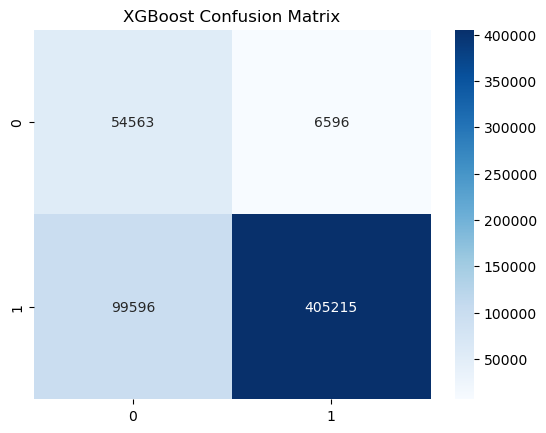

In [38]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.show()

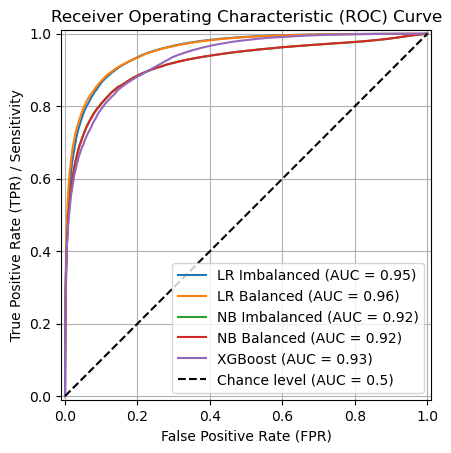

In [51]:
# Create the figure and axes
fig, ax = plt.subplots()

# Plot first model
RocCurveDisplay.from_estimator(lr, X_test_tfidf, y_test, ax=ax, name="LR Imbalanced")

# Plot second model on the SAME axes
RocCurveDisplay.from_estimator(lr_bal, X_test_tfidf, y_test, ax=ax, name="LR Balanced")

# Plot first model
RocCurveDisplay.from_estimator(nb, X_test_tfidf, y_test, ax=ax, name="NB Imbalanced")

# Plot second model on the SAME axes
RocCurveDisplay.from_estimator(nb_bal, X_test_tfidf, y_test, ax=ax, name="NB Balanced")

# Plot second model on the SAME axes
RocCurveDisplay.from_estimator(xgb, X_test_tfidf, y_test, ax=ax, name="XGBoost")

plt.plot([0, 1], [0, 1], 'k--', label='Chance level (AUC = 0.5)') # Add the random guess line

# 4. Finalize and show the plot
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Sensitivity')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [52]:
from sklearn.metrics import accuracy_score, f1_score

print("Logistic Regression F1:",
      f1_score(y_test, y_pred))

print("Naive Bayes F1:",
      f1_score(y_test, y_pred_nb))

print("XGBoost F1:",
      f1_score(y_test, y_pred_xgb))

Logistic Regression F1: 0.9285826515968869
Naive Bayes F1: 0.91190301972665
XGBoost F1: 0.8841485366923334


In [53]:
importances = xgb.feature_importances_

indices = np.argsort(importances)[-20:]

top_words = tfidf.get_feature_names_out()[indices]

pd.DataFrame({
    "word": top_words,
    "importance": importances[indices]
}).sort_values("importance", ascending=False)

,word,importance
19,dnf,0.021274
18,loved,0.020329
17,finish,0.018140
16,wait,0.014620
15,great,0.012196
14,boring,0.011479
13,amazing,0.011275
12,ok,0.010862
11,love,0.010845
10,ugh,0.010057


## Grid Search to Improve XGBoost Performance



In [66]:
# set up a gridsearch 
scale_weight = sum(y_train == 0) / sum(y_train == 1)

xgb_base = xgboost.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    scale_pos_weight=scale_weight,
    n_jobs=-1,
    random_state=42
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.6, 0.8]
}

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_tfidf, y_train)

print(grid_search.best_params_)

print(grid_search.best_score_)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13679 stored elements and shape (300, 5000)>

In [ ]:
best_xgb = grid_search.best_estimator_

y_pred = best_xgb.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

# Randomized Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": np.arange(100, 500, 50),
    "max_depth": np.arange(3, 10),
    "learning_rate": np.linspace(0.01, 0.2, 20),
    "subsample": np.linspace(0.7, 1.0, 10),
    "colsample_bytree": np.linspace(0.5, 1.0, 10),
    "gamma": [0, 0.1, 0.3, 0.5],
}

scale_weight = sum(y_train == 0) / sum(y_train == 1)

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_weight,
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=40,          # try 40 random combos
    scoring="f1",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_tfidf, y_train)

best_xgb = random_search.best_estimator_
print(random_search.best_params_)

In [77]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Logistic Regression Accuracy: 0.8795342509320282
Naive Bayes Accuracy: 0.8530045762142869


In [104]:
feature_names = tfidf.get_feature_names_out()
coeffs = lr.coef_[0]

top_positive = np.argsort(coeffs)[-200:]
top_negative = np.argsort(coeffs)[:200]
print("Top Positive Terms:")
print(feature_names[top_positive])
print("Top Negative Terms:")
print(feature_names[top_negative])

Top Positive Terms:
['tear' 'haha' 'nice' 'fresh' 'different' 'hea' 'exception' 'stop'
 'determined' 'packed' 'phenomenal' 'captivated' 'coaster' 'colleen'
 'perfectly' 'rereading' 'terrific' 'struggles' 'unusual' 'look' 'superb'
 'addicting' 'roller' 'damn' 'voluntarily' 'appreciated' 'spoil'
 'charming' 'brings' 'morning' 'delight' 'want' 'plenty' 'night' 'team'
 'wanting' 'tissues' 'enjoying' 'lives' 'strength' 'powerful' 'lovable'
 'cute' 'knew' 'admit' 'trust' 'truly' 'happiness' 'rooting' 'turner'
 'witty' 'cliffhanger' 'arc' 'smiling' 'grew' 'able' 'ms' 'overall'
 'although' 'worked' 'captivating' 'addictive' 'nos' 'next' 'guessing'
 'te' 'addicted' 'pleased' 'paced' 'writes' 'must' 'right' 'swoon'
 'engaging' 'amo' 'worried' 'series' 'makes' 'humor' 'sua' 'yummy'
 'adventure' 'amor' 'job' 'realistic' 'ready' 'secrets' 'today' 'raw'
 'wellwritten' 'rounded' 'relatable' 'action' 'crying' 'life' 'well'
 'seat' 'stayed' 'touching' 'honorable' 'devoured' 'loud' 'surprise'
 'heartwar

In [112]:
np.corrcoef(nb.feature_log_prob_[0], nb.feature_log_prob_[1])

array([[1.        , 0.76879475],
       [0.76879475, 1.        ]])

In [120]:
coeffs = nb.feature_log_prob_[1]

feature_names[np.argsort(nb.feature_log_prob_[1])[-200:]]

array(['soon', 'hero', 'without', 'enjoyable', 'received', 'comes',
       'page', 'friend', 'totally', 'heroine', 'anything', 'glad',
       'started', 'actually', 'kept', 'romantic', 'fantastic', 'look',
       'emotional', 'around', 'let', 'finally', 'copy', 'pretty', 'main',
       'coming', 'quite', 'scenes', 'quick', 'us', 'thats', 'highly',
       'far', 'done', 'couple', 'left', 'beginning', 'getting', 'day',
       'kind', 'job', 'since', 'wants', 'enjoy', 'yet', 'que', 'easy',
       'oh', 'hope', 'nice', 'whole', 'help', 'girl', 'woman', 'strong',
       'bad', 'work', 'friends', 'interesting', 'years', 'de', 'long',
       'take', 'must', 'thing', 'hard', 'makes', 'keep', 'sex', 'past',
       'enough', 'sure', 'plot', 'last', 'real', 'away', 'wanted',
       'times', 'wasnt', 'wow', 'part', 'give', 'second', 'shes',
       'forward', 'hes', 'honest', 'funny', 'wonderful', 'doesnt',
       'awesome', 'world', 'happy', 'absolutely', 'start', 'found',
       'different', 'ful

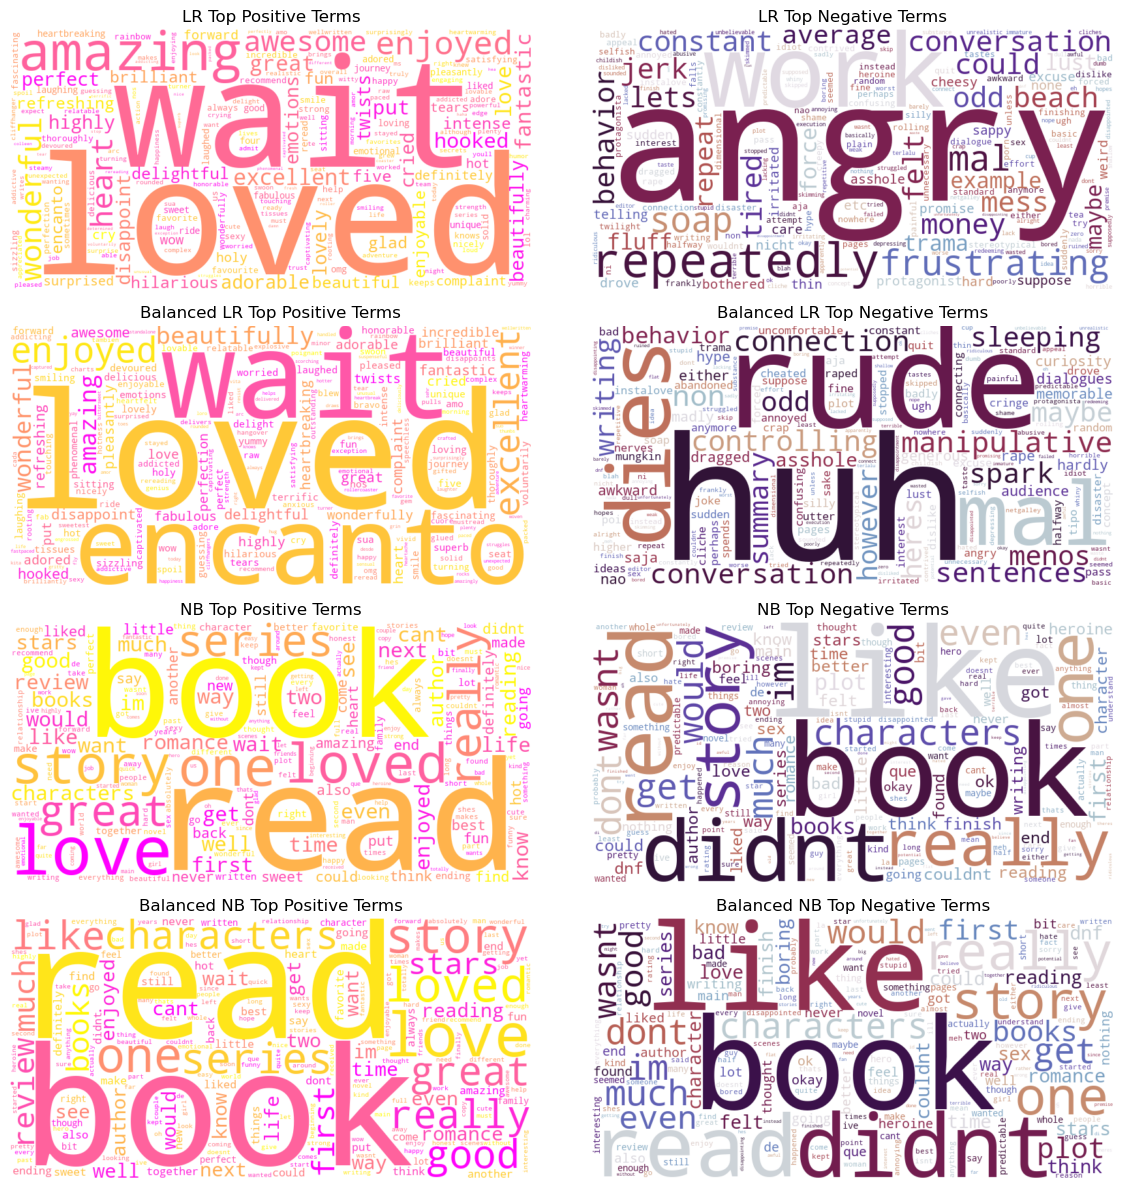

In [123]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

feature_names = tfidf.get_feature_names_out()

# Logistic Regression
coeffs = lr.coef_[0]
top_positive = np.argsort(coeffs)[-200:]
top_negative = np.argsort(coeffs)[:200]

lr_p_data =  dict(zip(feature_names[top_positive], coeffs[top_positive]))
lr_p_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap = "spring"
).generate_from_frequencies(lr_p_data)

lr_n_data =  dict(zip(feature_names[top_negative], coeffs[top_negative]))
lr_n_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap = "twilight_shifted"
).generate_from_frequencies(lr_n_data)

# Balanced Logistic Regression
coeffs = lr_bal.coef_[0]
top_positive = np.argsort(coeffs)[-200:]
top_negative = np.argsort(coeffs)[:200]

lr_bal_p_data =  dict(zip(feature_names[top_positive], coeffs[top_positive]))
lr_bal_p_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap = "spring"
).generate_from_frequencies(lr_bal_p_data)

lr_bal_n_data =  dict(zip(feature_names[top_negative], coeffs[top_negative]))
lr_bal_n_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap = "twilight_shifted"
).generate_from_frequencies(lr_bal_n_data)


# Multinomial NB
coeffs = nb.feature_log_prob_[1]
top_positive = np.argsort(coeffs)[-200:]

nb_p_data =  dict(zip(feature_names[top_positive], coeffs[top_positive]))
nb_p_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap = "spring"
).generate_from_frequencies(nb_p_data)

coeffs = nb.feature_log_prob_[0]
top_negative = np.argsort(coeffs)[-200:]

nb_n_data =  dict(zip(feature_names[top_negative], coeffs[top_negative]))
nb_n_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap = "twilight_shifted"
).generate_from_frequencies(nb_n_data)

# Balanced Multinomial NB
coeffs = nb.feature_log_prob_[1]
top_positive = np.argsort(coeffs)[-200:]

nb_bal_p_data =  dict(zip(feature_names[top_positive], coeffs[top_positive]))
nb_bal_p_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap = "spring"
).generate_from_frequencies(nb_bal_p_data)

coeffs = nb.feature_log_prob_[0]
top_negative = np.argsort(coeffs)[-200:]

nb_bal_n_data =  dict(zip(feature_names[top_negative], coeffs[top_negative]))
nb_bal_n_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap = "twilight_shifted"
).generate_from_frequencies(nb_bal_n_data)

# plt.figure(figsize=(8,6))
# plt.imshow(wordcloudn, interpolation="bilinear")
# plt.axis("off")
# plt.title("Top Negative Terms")
# plt.show()


# Create Two Panels (1 row, 2 columns)
fig, ax = plt.subplots(4, 2, figsize=(12, 12))

# Panel 1
ax[0,0].imshow(lr_p_wordcloud, interpolation='bilinear')
ax[0,0].set_title('LR Top Positive Terms')
ax[0,0].axis('off')

# Panel 2
ax[0,1].imshow(lr_n_wordcloud, interpolation='bilinear')
ax[0,1].set_title('LR Top Negative Terms')
ax[0,1].axis('off')

# Panel 1
ax[1,0].imshow(lr_bal_p_wordcloud, interpolation='bilinear')
ax[1,0].set_title('Balanced LR Top Positive Terms')
ax[1,0].axis('off')

# Panel 2
ax[1,1].imshow(lr_bal_n_wordcloud, interpolation='bilinear')
ax[1,1].set_title('Balanced LR Top Negative Terms')
ax[1,1].axis('off')

# Panel 1
ax[2,0].imshow(nb_p_wordcloud, interpolation='bilinear')
ax[2,0].set_title('NB Top Positive Terms')
ax[2,0].axis('off')

# Panel 2
ax[2,1].imshow(nb_n_wordcloud, interpolation='bilinear')
ax[2,1].set_title('NB Top Negative Terms')
ax[2,1].axis('off')

# Panel 1
ax[3,0].imshow(nb_bal_p_wordcloud, interpolation='bilinear')
ax[3,0].set_title('Balanced NB Top Positive Terms')
ax[3,0].axis('off')

# Panel 2
ax[3,1].imshow(nb_bal_n_wordcloud, interpolation='bilinear')
ax[3,1].set_title('Balanced NB Top Negative Terms')
ax[3,1].axis('off')

plt.tight_layout()
plt.show()

In [124]:
def lr_predict_review(text):
    cleaned = text.lower()
    vec = tfidf.transform([cleaned])
    pred = lr.predict(vec)[0]
    return "Positive" if pred == 1 else "Negative"

def lr_bal_predict_review(text):
    cleaned = text.lower()
    vec = tfidf.transform([cleaned])
    pred = lr_bal.predict(vec)[0]
    return "Positive" if pred == 1 else "Negative"

def nb_predict_review(text):
    cleaned = text.lower()
    vec = tfidf.transform([cleaned])
    pred = nb.predict(vec)[0]
    return "Positive" if pred == 1 else "Negative"

def nb_bal_predict_review(text):
    cleaned = text.lower()
    vec = tfidf.transform([cleaned])
    pred = nb_bal.predict(vec)[0]
    return "Positive" if pred == 1 else "Negative"

# Testing

Run tests on synthetic reviews with varying degrees of sentiment ambiguity 

In [126]:
new_review = "This book was everything I was hoping for and more I cant wait for the next book to come out"

print(lr_predict_review(new_review))
print(lr_bal_predict_review(new_review))
print(nb_predict_review(new_review))
print(nb_bal_predict_review(new_review))

Positive
Positive
Positive
Positive


In [127]:
new_review = "I could not stand this book dnf"

print(lr_predict_review(new_review))
print(lr_bal_predict_review(new_review))
print(nb_predict_review(new_review))
print(nb_bal_predict_review(new_review))

Negative
Negative
Negative
Negative


In [129]:
new_review = "Overall this was an enjoyable read with a few strong moments even though the pacing felt a bit slow in parts"

print(lr_predict_review(new_review))
print(lr_bal_predict_review(new_review))
print(nb_predict_review(new_review))
print(nb_bal_predict_review(new_review))

Positive
Negative
Positive
Negative


In [167]:
synthetic_reviews = [
    # --- STRONGLY POSITIVE ---
    ("This book was absolutely fantastic and kept me hooked from start to finish.", 1),
    ("I loved the characters and the story was beautifully written.", 1),
    ("An amazing read that I would highly recommend to anyone.", 1),
    ("The writing style was engaging and the plot was very compelling.", 1),
    ("One of the best books I’ve read in years.", 1),

    # --- MODERATELY POSITIVE ---
    ("Overall, a very enjoyable read with strong character development.", 1),
    ("I liked the story even though some parts felt slow.", 1),
    ("It was a solid book with a satisfying ending.", 1),
    ("The atmosphere was great and I stayed interested throughout.", 1),
    ("Not perfect, but definitely worth reading.", 1),

    # --- SLIGHTLY POSITIVE (BOUNDARY TESTS) ---
    ("It had some good moments, though it dragged in places.", 1),
    ("I appreciated the writing even if the plot was uneven.", 1),
    ("A decent book with a few memorable scenes.", 1),
    ("It took a while to get interesting, but I ended up liking it.", 1),
    ("I wouldn’t reread it, but I’m glad I finished it.", 1),

    # --- SLIGHTLY NEGATIVE (BOUNDARY TESTS) ---
    ("There were a few interesting ideas, but I felt mostly underwhelmed.", 0),
    ("Not terrible, but I wouldn’t recommend it.", 0),
    ("It was okay, though I lost interest halfway through.", 0),
    ("Some good parts, but overall disappointing.", 0),
    ("I finished it, but it felt like a chore.", 0),

    # --- MODERATELY NEGATIVE ---
    ("The story had potential but was badly executed.", 0),
    ("I didn’t connect with the characters at all.", 0),
    ("It started strong but quickly became dull.", 0),
    ("The pacing was slow and the ending felt rushed.", 0),
    ("Overall, it just didn’t work for me.", 0),

            # --- CLEARLY NEGATIVE ---
    ("I found this book very boring and difficult to finish.", 0),
    ("The plot made no sense and the characters were flat.", 0),
    ("This was disappointing and poorly written.", 0),
    ("I struggled to stay interested the entire time.", 0),
    ("One of the worst books I’ve read.", 0),
]

In [175]:
test_df = pd.DataFrame(synthetic_reviews, columns=["review", "true_label"])
# sg = ["STRONGLY POSITIVE"]*5 + ["MODERATELY POSITIVE"]*5 + ["SLIGHTLY POSITIVE"]*5 + ["SLIGHTLY NEGATIVE"]*5 + ["MODERATELY NEGATIVE"]*5 + ["CLEARLY NEGATIVE"]*5
sg = [1]*5 + [2]*5 + [3]*5 + [4]*5 + [5]*5 + [6]*5
test_df['sentiment_group'] = sg
test_df['sentiment_group'] = test_df['sentiment_group'].astype('category')
test_df.head(10)

,review,true_label,sentiment_group
0,This book was absolutely fantastic and kept me...,1,1
1,I loved the characters and the story was beaut...,1,1
2,An amazing read that I would highly recommend ...,1,1
3,The writing style was engaging and the plot wa...,1,1
4,One of the best books I’ve read in years.,1,1
5,"Overall, a very enjoyable read with strong cha...",1,2
6,I liked the story even though some parts felt ...,1,2
7,It was a solid book with a satisfying ending.,1,2
8,The atmosphere was great and I stayed interest...,1,2
9,"Not perfect, but definitely worth reading.",1,2


In [176]:
def lr_predict_review(text):
    cleaned = text.lower()
    vec = tfidf.transform([cleaned])
    pred = lr.predict(vec)[0]
    return pred #"Positive" if pred == 1 else "Negative"

def lr_bal_predict_review(text):
    cleaned = text.lower()
    vec = tfidf.transform([cleaned])
    pred = lr_bal.predict(vec)[0]
    return pred #"Positive" if pred == 1 else "Negative"

def nb_predict_review(text):
    cleaned = text.lower()
    vec = tfidf.transform([cleaned])
    pred = nb.predict(vec)[0]
    return pred #"Positive" if pred == 1 else "Negative"

def nb_bal_predict_review(text):
    cleaned = text.lower()
    vec = tfidf.transform([cleaned])
    pred = nb_bal.predict(vec)[0]
    return pred #"Positive" if pred == 1 else "Negative"

test_df["lr_predicted"] = test_df["review"].apply(lambda x: lr_predict_review(x))
test_df["lr_bal_predicted"] = test_df["review"].apply(lambda x: lr_bal_predict_review(x))
test_df["nb_predicted"] = test_df["review"].apply(lambda x: nb_predict_review(x))
test_df["nb_bal_predicted"] = test_df["review"].apply(lambda x: nb_bal_predict_review(x))

print("Logistic Regression Accuracy:", accuracy_score(test_df['true_label'], test_df["lr_predicted"]))
print("Balanced Logistic Regression Accuracy:", accuracy_score(test_df['true_label'], test_df["lr_bal_predicted"]))
print("Naive Bayes Accuracy:", accuracy_score(test_df['true_label'], test_df["nb_predicted"]))
print("Balanced Naive Bayes Accuracy:", accuracy_score(test_df['true_label'], test_df["nb_bal_predicted"]))

Logistic Regression Accuracy: 0.9
Balanced Logistic Regression Accuracy: 0.8
Naive Bayes Accuracy: 0.7
Balanced Naive Bayes Accuracy: 0.8


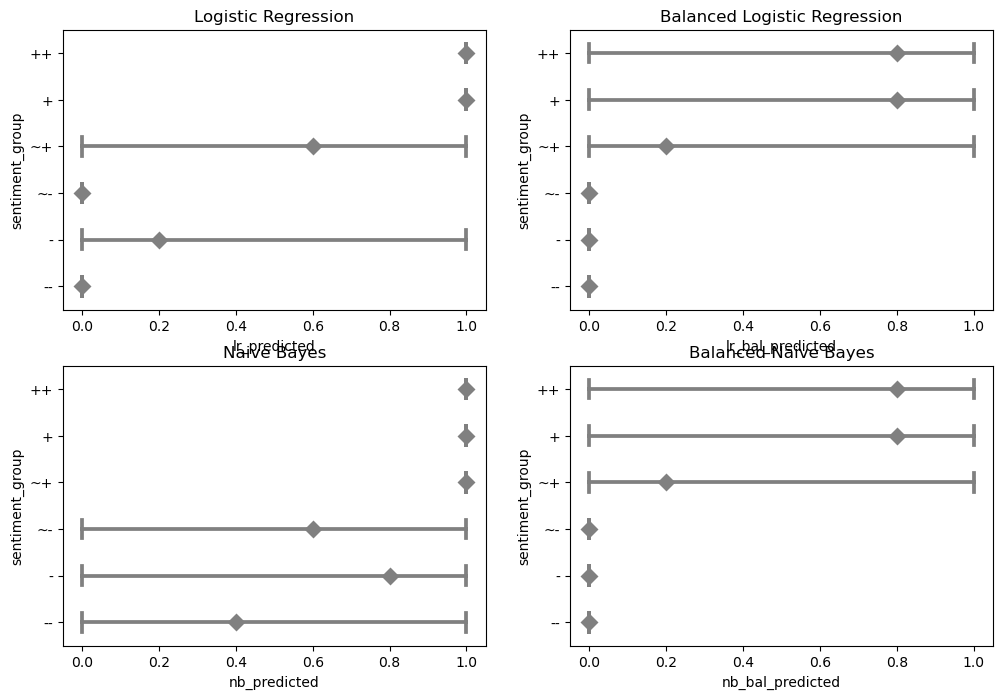

In [199]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.pointplot(
    data=test_df, x="lr_predicted", y='sentiment_group',
    errorbar=("pi", 100), capsize=.4,
    color=".5", linestyle="none", marker="D", ax=axes[0,0]
)
sns.pointplot(
    data=test_df, x="lr_bal_predicted", y='sentiment_group',
    errorbar=("pi", 100), capsize=.4,
    color=".5", linestyle="none", marker="D", ax=axes[0,1]
)
sns.pointplot(
    data=test_df, x="nb_predicted", y='sentiment_group',
    errorbar=("pi", 100), capsize=.4,
    color=".5", linestyle="none", marker="D", ax=axes[1,0]
)
sns.pointplot(
    data=test_df, x="nb_bal_predicted", y='sentiment_group',
    errorbar=("pi", 100), capsize=.4,
    color=".5", linestyle="none", marker="D", ax=axes[1,1]
)
axes[0,0].set_title("Logistic Regression")
axes[0,1].set_title("Balanced Logistic Regression")
axes[1,0].set_title("Naive Bayes")
axes[1,1].set_title("Balanced Naive Bayes")

sg = ["++", "+", "~+", "~-", "-", "--"]
axes[0,0].set_yticks([0,1,2,3,4,5], sg)
axes[0,1].set_yticks([0,1,2,3,4,5], sg)
axes[1,0].set_yticks([0,1,2,3,4,5], sg)
axes[1,1].set_yticks([0,1,2,3,4,5], sg)


<Axes: >

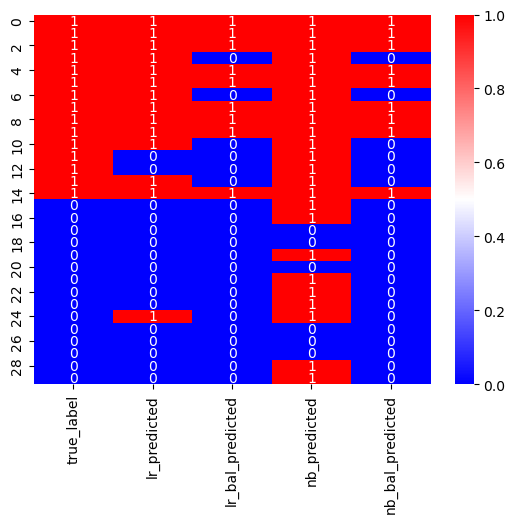

In [205]:
hm = test_df.iloc[:, [1,3,4,5,6]]
sns.heatmap(hm, annot=True, fmt="d", cmap="bwr")

In [25]:
X_test

1800556    always enjoy new book jak first long time isnt...
3456943    price drop httpamzntohxzfwe read book twice fi...
913362     stars series keeps getting better better many ...
1271245    se hall angela graham done yet filthy foreign ...
451477     received arc via netgalley exchange honest rev...
                                 ...                        
2659392    im thrilled carole didnt fail disappoint new n...
387996     stars sweet read like pete sweet slow love reagan
823615     loved book excited found released wish one lon...
1027930    whole series okay guess ending predictable ski...
1598684    actually finished yesterday much homework didn...
Name: clean_review, Length: 565970, dtype: object

In [26]:
analysis_df = pd.DataFrame({
    "review": X_test,
    "true_label": y_test,
    "predicted_label": y_pred
}).reset_index(drop=True)

analysis_df.head()

,review,true_label,predicted_label
0,always enjoy new book jak first long time isnt...,1,1
1,price drop httpamzntohxzfwe read book twice fi...,1,1
2,stars series keeps getting better better many ...,1,1
3,se hall angela graham done yet filthy foreign ...,1,1
4,received arc via netgalley exchange honest rev...,1,1


In [27]:
print(classification_report(analysis_df["true_label"],
                            analysis_df["predicted_label"]))

              precision    recall  f1-score   support

           0       0.82      0.58      0.68     61159
           1       0.95      0.98      0.97    504811

    accuracy                           0.94    565970
   macro avg       0.89      0.78      0.83    565970
weighted avg       0.94      0.94      0.94    565970



In [28]:
errors = analysis_df[
    analysis_df["true_label"] != analysis_df["predicted_label"]
]

print("Total misclassified:", len(errors))
errors.head()

Total misclassified: 33093


,review,true_label,predicted_label
5,super weird,0,1
8,well free,0,1
12,pude quitarme la sensacion de que estaba leyen...,0,1
29,love pov p sayang endingnya sepertinya terlalu...,1,0
30,maybe maybe im becoming jaded result harder im...,1,0


In [29]:
false_positives = analysis_df[
    (analysis_df["true_label"] == 0) &
    (analysis_df["predicted_label"] == 1)
]

false_positives.sample(5)

,review,true_label,predicted_label
386111,didnt enjoy one quite much first one wasnt qui...,0,1
59318,fans carly phillips light sexy entertaining re...,0,1
52008,romance story ending leaves reader wondering t...,0,1
525334,trama quando morgan desilva trova degli antich...,0,1
235805,reread completely forgot slept hs identical tw...,0,1


In [30]:
false_negatives = analysis_df[
    (analysis_df["true_label"] == 1) &
    (analysis_df["predicted_label"] == 0)
]

false_negatives.sample(5)

,review,true_label,predicted_label
200307,la historia puede ser mas cliche pero e e n c ...,1,0
457569,wtfffffff feel like wasted hour spent wisely t...,1,0
403026,one know read enjoy try desperately tried litt...,1,0
524834,hopes work two p aww sweet story quick read on...,1,0
311558,dydydydydy dont leave hanging really hate auth...,1,0
